In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import time
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from keras.datasets import cifar10
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

x_train_full = x_train_full.reshape(x_train_full.shape[0], -1)
x_test_full = x_test_full.reshape(x_test_full.shape[0], -1)
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

train_df = pd.DataFrame(x_train_full)
train_df['label'] = y_train_full

ids_animals = [2, 3, 4, 5, 6, 7]
ids_vehicles = [0, 1, 8, 9]      

y_train = np.where(train_df['label'].isin(ids_vehicles), 1, -1).astype(np.float32)
y_test = np.where(np.isin(y_test_full, ids_vehicles), 1, -1).astype(np.float32)

x_train = train_df.drop(columns=['label']).values

In [10]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.astype(np.float32))
x_test_scaled = scaler.transform(x_test_full.astype(np.float32))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x_train_final, x_val, y_train_final, y_val = sklearn.model_selection.train_test_split(
    x_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)
x_train_tensor = torch.tensor(x_train_final, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train_final, device=device).view(-1, 1)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32, device=device)
y_val_tensor = torch.tensor(y_val, device=device).view(-1, 1)

x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test, device=device).view(-1, 1)

#train Loader

train_ds = TensorDataset(x_train_tensor, y_train_tensor)
trainloader = DataLoader(train_ds, batch_size=256, shuffle=True)

#validation Loader
val_ds = TensorDataset(x_val_tensor, y_val_tensor)
validationloader = DataLoader(val_ds, batch_size=1024, shuffle=False)

#test Loader
test_ds = TensorDataset(x_test_tensor, y_test_tensor)
testloader = DataLoader(test_ds, batch_size=1024, shuffle=False)

🚀 Training Started on cuda...
Epoch [1/100] - Train Loss: 0.4612 - Acc: 81.72% | Val Loss: 0.3826 - Val Acc: 85.00%
Epoch [2/100] - Train Loss: 0.3886 - Acc: 84.56% | Val Loss: 0.3576 - Val Acc: 85.96%
Epoch [3/100] - Train Loss: 0.3658 - Acc: 85.53% | Val Loss: 0.3332 - Val Acc: 87.09%
Epoch [4/100] - Train Loss: 0.3477 - Acc: 86.36% | Val Loss: 0.3465 - Val Acc: 86.28%
Epoch [5/100] - Train Loss: 0.3367 - Acc: 86.65% | Val Loss: 0.3202 - Val Acc: 87.61%
Epoch [6/100] - Train Loss: 0.3246 - Acc: 87.19% | Val Loss: 0.3140 - Val Acc: 87.57%
Epoch [7/100] - Train Loss: 0.3204 - Acc: 87.38% | Val Loss: 0.3110 - Val Acc: 87.96%
Epoch [8/100] - Train Loss: 0.3144 - Acc: 87.57% | Val Loss: 0.3048 - Val Acc: 88.00%
Epoch [9/100] - Train Loss: 0.3070 - Acc: 87.86% | Val Loss: 0.2992 - Val Acc: 88.25%
Epoch [10/100] - Train Loss: 0.3018 - Acc: 88.18% | Val Loss: 0.3030 - Val Acc: 87.97%
Epoch [11/100] - Train Loss: 0.2984 - Acc: 88.18% | Val Loss: 0.3028 - Val Acc: 88.25%
Epoch [12/100] - Train

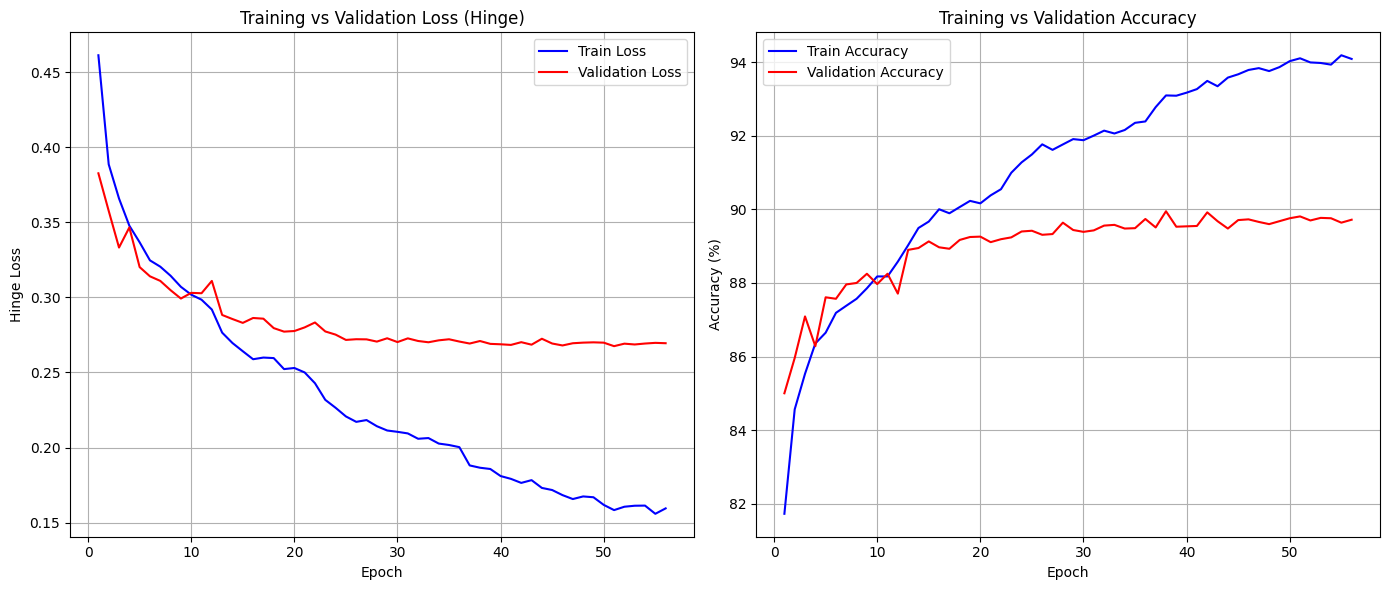

In [24]:
#MLP
class HingeMLP(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(HingeMLP, self).__init__()
        
        self.hidden = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.45) 
        )
        
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.output(x)
        return x
    
model = HingeMLP(input_size=x_train_scaled.shape[1], hidden_size=256).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # L2 Regularization
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

#TRAIN + Early Stopping
num_epochs = 100
patience = 5
best_loss = float('inf')
counter = 0
best_model = None

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"🚀 Training Started on {device}...")

#START TIMER 
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        optimizer.zero_grad()
        
        outputs = model(inputs)
        
        #HINGE LOSS
        loss = torch.mean(torch.clamp(1 - labels * outputs, min=0))
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # Training Accuracy
        preds = torch.sign(outputs)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    # Statistics per epoch
    train_loss = running_loss / len(trainloader)
    train_acc = 100.0 * correct / total

    #Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in validationloader:
            outputs = model(inputs)
            
            # Validation Hinge Loss
            loss = torch.mean(torch.clamp(1 - labels * outputs, min=0))
            val_loss += loss.item()
            
            # Validation Accuracy
            preds = torch.sign(outputs)
            total_val += labels.size(0)
            correct_val += (preds == labels).sum().item()

    val_loss /= len(validationloader)
    val_acc = 100.0 * correct_val / total_val
    
    # Update Scheduler
    scheduler.step(val_loss)

    # Store losses and accuracies for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

    #Early Stopping Logic 
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0 
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹️ Early stopping at epoch {epoch+1}! Best Val Loss: {best_loss:.4f}")
            break

#END TIMER
end_time = time.time()
training_time = end_time - start_time

#Load Best Model
if best_model:
    model.load_state_dict(best_model)

print("✅ Training finished!")
print(f"⏱️ Total Training Time: {training_time:.4f} seconds")

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 6))

#Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Train Loss')
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.title('Training vs Validation Loss (Hinge)')
plt.legend()
plt.grid(True)

#Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, 'b-', label='Train Accuracy')
plt.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

------------------------------------------------------------
📊 DETAILED PERFORMANCE REPORT (TEST SET)
------------------------------------------------------------
🏆 Final Test Accuracy: 89.41%
------------------------------------------------------------
               precision    recall  f1-score   support

 Animals (-1)     0.9027    0.9230    0.9127      6000
Vehicles (+1)     0.8805    0.8508    0.8654      4000

     accuracy                         0.8941     10000
    macro avg     0.8916    0.8869    0.8890     10000
 weighted avg     0.8938    0.8941    0.8938     10000

------------------------------------------------------------


<Figure size 800x800 with 0 Axes>

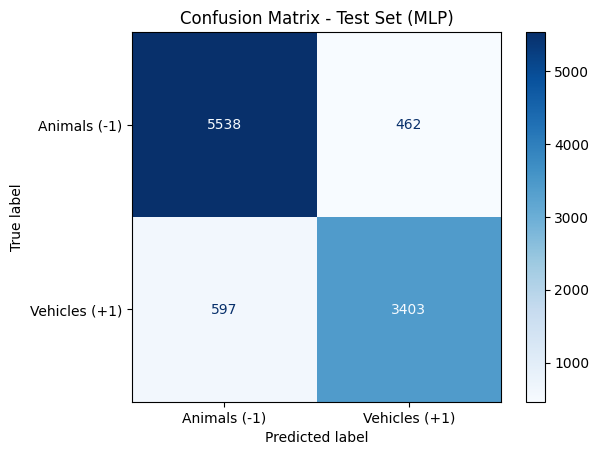

In [ ]:
#EVALUATION ON TEST SET
all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, labels in testloader: 
        outputs = model(inputs)
        preds = torch.sign(outputs)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(labels.cpu().numpy().flatten())

y_pred_np = np.array(all_preds)
y_true_np = np.array(all_targets)

y_pred_np = np.where(y_pred_np == 0, -1, y_pred_np)

print("-" * 60)
print("-" * 60)

#Accuracy
acc = accuracy_score(y_true_np, y_pred_np)
print(f"🏆 Final Test Accuracy: {acc * 100:.2f}%")
print("-" * 60)

#Classification Report (Precision, Recall, F1)
print(classification_report(
    y_true_np, 
    y_pred_np, 
    labels=[-1, 1], 
    target_names=['Animals (-1)', 'Vehicles (+1)'],
    digits=4
))
print("-" * 60)

#Confusion Matrix
cm = confusion_matrix(y_true_np, y_pred_np, labels=[-1, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Animals (-1)', 'Vehicles (+1)'])

plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d') # values_format='d' for integer values
plt.title("Confusion Matrix - Test Set (MLP)")
plt.show()

In [26]:
PATH = 'best_mlp_weights.pth'
torch.save(model.state_dict(), PATH)


--- Report for NearestCentroid ---
               precision    recall  f1-score   support

 Animals (-1)       0.78      0.71      0.74      6000
Vehicles (+1)       0.62      0.70      0.65      4000

     accuracy                           0.71     10000
    macro avg       0.70      0.70      0.70     10000
 weighted avg       0.71      0.71      0.71     10000


--- Report for NearestNeighbors1 ---
               precision    recall  f1-score   support

 Animals (-1)       0.80      0.89      0.84      6000
Vehicles (+1)       0.80      0.67      0.73      4000

     accuracy                           0.80     10000
    macro avg       0.80      0.78      0.78     10000
 weighted avg       0.80      0.80      0.80     10000


--- Report for NearestNeighbors3 ---
               precision    recall  f1-score   support

 Animals (-1)       0.80      0.90      0.85      6000
Vehicles (+1)       0.82      0.66      0.73      4000

     accuracy                           0.81     10000


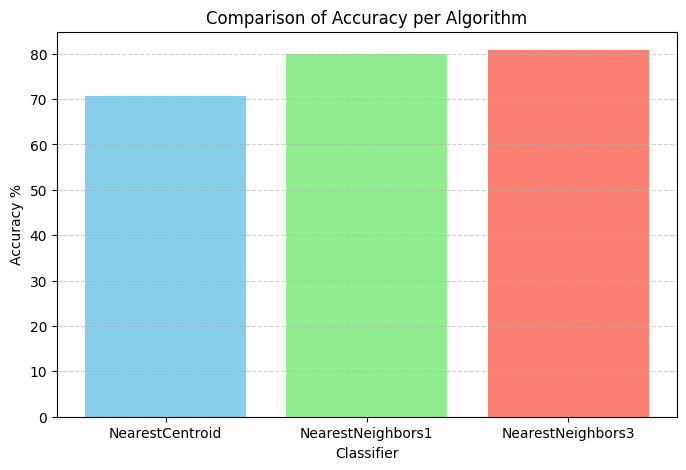

In [ ]:
#Nearest Neighbors Classifiers KNN 1 & 3,Nearest Centroid

models = {
    'NearestCentroid': NearestCentroid(),
    'NearestNeighbors1': KNeighborsClassifier(n_neighbors=1, weights='distance', metric='euclidean'),
    'NearestNeighbors3': KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')
}
acc_dict={}
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    clf_preds = model.predict(x_test_scaled)

    print(f"\n--- Report for {name} ---")
    print(classification_report(
        y_test, clf_preds,
        target_names=['Animals (-1)', 'Vehicles (+1)']
    ))
    acc = accuracy_score(y_test, clf_preds)
    acc_dict[name] = acc * 100

# bar plot for accuracy
plt.figure(figsize=(8,5))
colors = ['skyblue', 'lightgreen', 'salmon']
plt.bar(acc_dict.keys(), acc_dict.values(), color=colors)
plt.ylabel('Accuracy %')
plt.xlabel('Classifier')
plt.title('Comparison of Accuracy per Algorithm')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.show()

In [8]:
models = {
    'NearestCentroid': NearestCentroid(),
    'NearestNeighbors1': KNeighborsClassifier(n_neighbors=1, weights='distance', metric='euclidean'),
    'NearestNeighbors3': KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')
}

In [19]:
#Measure Training Time 
time_dict = {}

for name, model in models.items():
    time_start = time.time()
    model.fit(x_train_scaled, y_train)
    time_end = time.time()
    
    training_time = time_end - time_start
    time_dict[name] = training_time
    
    print(f"Training time for {name}: {training_time:.4f} seconds")

print("\nFinal Time Dictionary:", time_dict)

Training time for NearestCentroid: 1.3188 seconds
Training time for NearestNeighbors1: 0.0761 seconds
Training time for NearestNeighbors3: 0.0572 seconds

Final Time Dictionary: {'NearestCentroid': 1.3187878131866455, 'NearestNeighbors1': 0.07613110542297363, 'NearestNeighbors3': 0.057218313217163086}
